This notebook demonstrates a simple linear regression analysis using R to model Salary based on Years of Experience.

This section reads a csv file called "regression_data.csv" from the working directory to create and store a table in a variable called "dataset"

In [4]:
dataset <- read.csv("regression_data.csv")

This line creates a linear model fit using the R function "lm()" for the previous dataset, where Salary is the outcome (y variable), that is predicted YearsExperience (x variable). It assigns the model to a variable called "model".

In [5]:
model <- lm(Salary ~ YearsExperience, data=dataset)

This section uses ggplot2 syntax from R studio to overlay a linear regression model to the previous dataset/scatterplot. geom_point creates points on a scatterplot from dataset. geom_line connects points into a line on the graph. annotate add the string containing the slope intercept formula and R^2 value onto the graph at a location hard coded. 

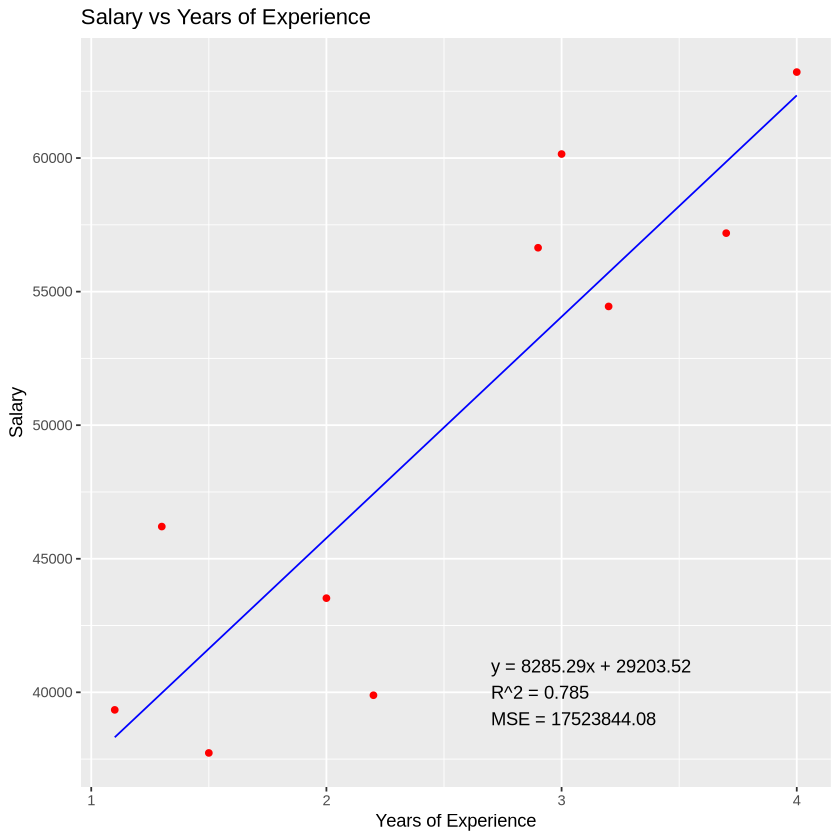

In [6]:
library(ggplot2) #opens ggplot2 library
ggplot() + #creates a new project where "+" adds a new layer
    geom_point(aes(x = dataset$YearsExperience, y = dataset$Salary), colour = 'red') +
    geom_line(aes(x = dataset$YearsExperience, y = predict(model, newdata = dataset)), colour = 'blue') +
    ggtitle('Salary vs Years of Experience') +
    xlab ('Years of Experience') +
    ylab ('Salary') +
    annotate(
        "text", 
        x = 2.7,
        y = 40000,
        label = paste0(
            "y = ", round(coef(model)[2], 2), "x + ", round(coef(model)[1], 2),
            "\nR^2 = ", round(summary(model)$r.squared, 3),
            "\nMSE = ", round(mean(residuals(model)^2), 2)
            ), 
        hjust = 0
        )